In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('../data/raw/tashkent_houses.xlsx')
df.head()

,address,district,rooms,size,level,max_levels,price,lat,lng
0,"город Ташкент, Yunusobod район, Юнусабад 8-й к...",Yunusobod,3,57.0,4,4,52000,41.371471,69.281049
1,"город Ташкент, Yakkasaroy район, 1-й тупик Шот...",Yakkasaroy,2,52.0,4,5,56000,41.291115,69.261104
2,"город Ташкент, Chilonzor район, Чиланзар 2-й к...",Chilonzor,2,42.0,4,4,37000,41.280784,69.223683
3,"город Ташкент, Chilonzor район, Чиланзар 9-й к...",Chilonzor,3,65.0,1,4,49500,41.290163,69.196862
4,"город Ташкент, Chilonzor район, площадь Актепа",Chilonzor,3,70.0,3,5,55000,41.300156,69.210831


# Column Descriptions
- `location` - address of the house being sold
- `district` - district where the house is located
- `rooms` - number of rooms
- `size` - house area (sq.m)
- `level` - floor where the house is located
- `max_levels` - total number of floors
- `price` - house price

In [3]:
df.shape

(7421, 9)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7421 entries, 0 to 7420
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   address     7421 non-null   str    
 1   district    7421 non-null   str    
 2   rooms       7421 non-null   int64  
 3   size        7421 non-null   float64
 4   level       7421 non-null   int64  
 5   max_levels  7421 non-null   int64  
 6   price       7421 non-null   int64  
 7   lat         7421 non-null   float64
 8   lng         7421 non-null   float64
dtypes: float64(3), int64(4), str(2)
memory usage: 521.9 KB


In [5]:
df.isna().sum()

address       0
district      0
rooms         0
size          0
level         0
max_levels    0
price         0
lat           0
lng           0
dtype: int64

In [6]:
df.describe()

,rooms,size,level,max_levels,price,lat,lng
count,7421.000000,7421.000000,7421.000000,7421.000000,7421.000000,7421.000000,7421.000000
mean,2.619728,73.150726,3.699367,6.031397,59117.618919,41.303620,69.256615
std,1.076887,36.999670,2.239028,2.607673,46701.090308,0.033771,0.059061
min,1.000000,14.000000,1.000000,1.000000,10500.000000,41.186375,69.148915
25%,2.000000,50.000000,2.000000,4.000000,35000.000000,41.281265,69.205802
50%,3.000000,65.000000,3.000000,5.000000,46500.000000,41.296388,69.260189
75%,3.000000,85.000000,5.000000,9.000000,66847.000000,41.324956,69.293713
max,10.000000,456.000000,19.000000,25.000000,800000.000000,41.424522,69.588687


In [7]:
df.corr(numeric_only=True)

,rooms,size,level,max_levels,price,lat,lng
rooms,1.000000,0.787697,0.139826,0.184896,0.552582,0.015092,0.013279
size,0.787697,1.000000,0.160907,0.276208,0.781830,0.030097,0.066416
level,0.139826,0.160907,1.000000,0.593245,0.059276,-0.027811,0.045332
max_levels,0.184896,0.276208,0.593245,1.000000,0.219737,-0.064064,0.039507
price,0.552582,0.781830,0.059276,0.219737,1.000000,0.015636,0.070309
lat,0.015092,0.030097,-0.027811,-0.064064,0.015636,1.000000,0.528706
lng,0.013279,0.066416,0.045332,0.039507,0.070309,0.528706,1.000000


In [8]:
df

,address,district,rooms,size,level,max_levels,price,lat,lng
0,"город Ташкент, Yunusobod район, Юнусабад 8-й к...",Yunusobod,3,57.0,4,4,52000,41.371471,69.281049
1,"город Ташкент, Yakkasaroy район, 1-й тупик Шот...",Yakkasaroy,2,52.0,4,5,56000,41.291115,69.261104
2,"город Ташкент, Chilonzor район, Чиланзар 2-й к...",Chilonzor,2,42.0,4,4,37000,41.280784,69.223683
3,"город Ташкент, Chilonzor район, Чиланзар 9-й к...",Chilonzor,3,65.0,1,4,49500,41.290163,69.196862
4,"город Ташкент, Chilonzor район, площадь Актепа",Chilonzor,3,70.0,3,5,55000,41.300156,69.210831
...,...,...,...,...,...,...,...,...,...
7416,"город Ташкент, Yashnobod район, Городок Авиаст...",Yashnobod,1,38.0,5,5,24500,41.292252,69.341907
7417,"город Ташкент, Yashnobod район, 1-й проезд Ави...",Yashnobod,2,49.0,1,4,32000,41.289606,69.343485
7418,"город Ташкент, Shayhontohur район, Зульфияханум",Shayhontohur,2,64.0,3,9,40000,41.331415,69.268901
7419,"город Ташкент, Mirzo Ulugbek район, Буюк Ипак ...",Mirzo Ulugbek,1,18.0,1,4,11000,41.310487,69.292223


In [9]:
df = df.drop('address', axis=1)

In [10]:
df.head()

,district,rooms,size,level,max_levels,price,lat,lng
0,Yunusobod,3,57.0,4,4,52000,41.371471,69.281049
1,Yakkasaroy,2,52.0,4,5,56000,41.291115,69.261104
2,Chilonzor,2,42.0,4,4,37000,41.280784,69.223683
3,Chilonzor,3,65.0,1,4,49500,41.290163,69.196862
4,Chilonzor,3,70.0,3,5,55000,41.300156,69.210831


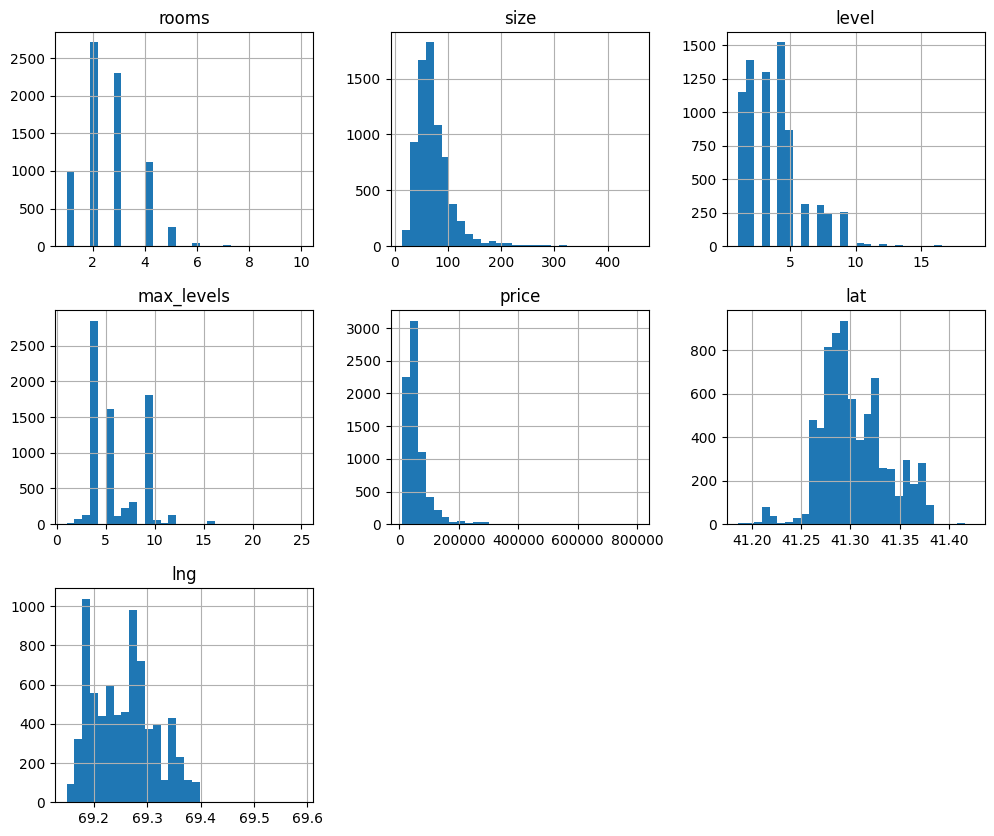

In [11]:
df.hist(figsize=(12, 10),bins=30)
plt.show()

In [ ]:
# Conclusion: most houses have price up to 400,000 and size up to 350 sq.m. Also, most houses were built in 2010-2020.
# We will filter the dataset to price <= 400,000 and size <= 350 sq.m to make the prediction more accurate.

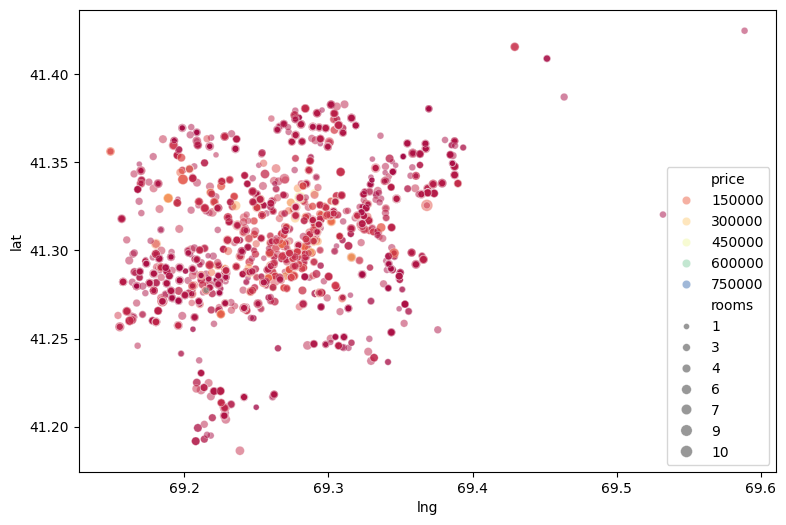

In [12]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df,y='lat',x='lng' ,hue='price',alpha=0.5,palette='Spectral',size='rooms')
plt.show()

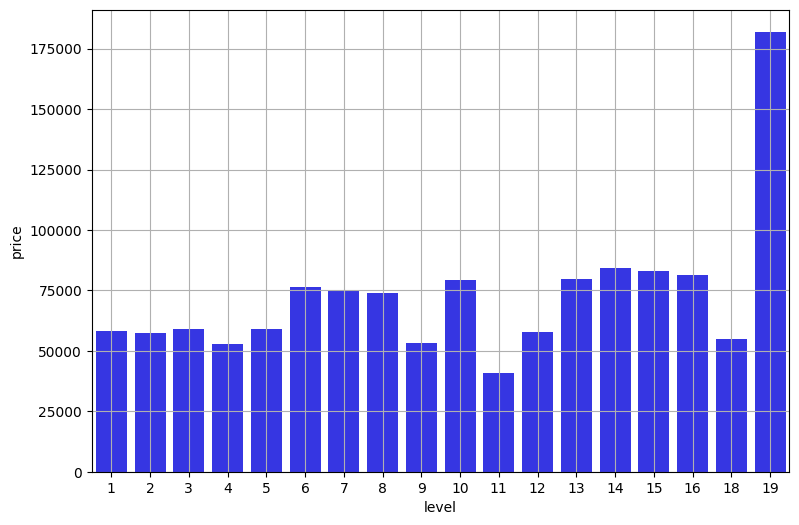

In [13]:
plt.figure(figsize=(9,6))
sns.barplot(y='price', x='level', data=df, color='blue', alpha=0.9, errorbar=None)
plt.grid()
plt.show()

In [14]:
df.corrwith(df['price'], numeric_only=True).sort_values(ascending=False)

price         1.000000
size          0.781830
rooms         0.552582
max_levels    0.219737
lng           0.070309
level         0.059276
lat           0.015636
dtype: float64

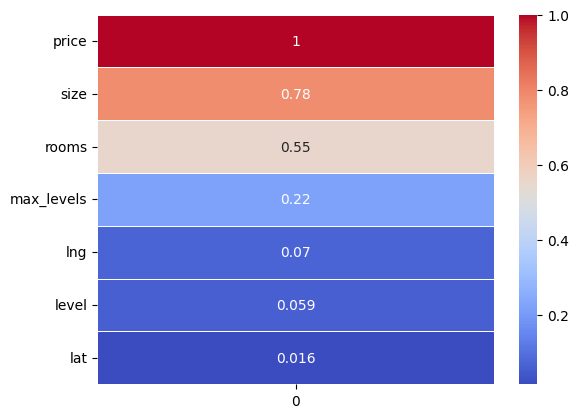

In [15]:
sns.heatmap(df.corrwith(df['price'], numeric_only=True).sort_values(ascending=False).to_frame(), annot=True, cmap='coolwarm', linewidths=0.7)
plt.show()

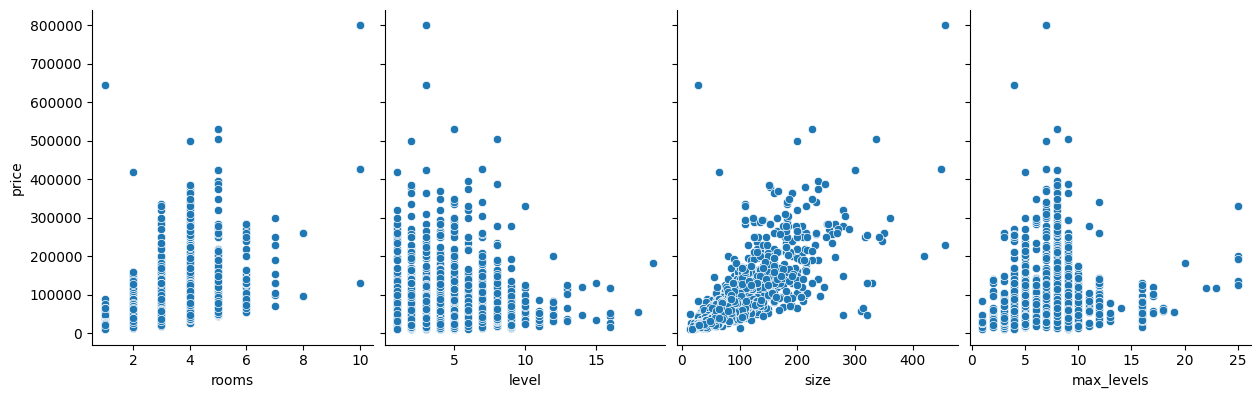

In [16]:
sns.pairplot(df, x_vars=['rooms', 'level', 'size', 'max_levels'], y_vars='price', height=4, aspect=0.8)
plt.show()

In [17]:
df

,district,rooms,size,level,max_levels,price,lat,lng
0,Yunusobod,3,57.0,4,4,52000,41.371471,69.281049
1,Yakkasaroy,2,52.0,4,5,56000,41.291115,69.261104
2,Chilonzor,2,42.0,4,4,37000,41.280784,69.223683
3,Chilonzor,3,65.0,1,4,49500,41.290163,69.196862
4,Chilonzor,3,70.0,3,5,55000,41.300156,69.210831
...,...,...,...,...,...,...,...,...
7416,Yashnobod,1,38.0,5,5,24500,41.292252,69.341907
7417,Yashnobod,2,49.0,1,4,32000,41.289606,69.343485
7418,Shayhontohur,2,64.0,3,9,40000,41.331415,69.268901
7419,Mirzo Ulugbek,1,18.0,1,4,11000,41.310487,69.292223


In [ ]:
# Feature Engineering
df['room_size'] = df['size'] / df['rooms']
df.head()

,district,rooms,size,level,max_levels,price,lat,lng,room_size
0,Yunusobod,3,57.0,4,4,52000,41.371471,69.281049,19.000000
1,Yakkasaroy,2,52.0,4,5,56000,41.291115,69.261104,26.000000
2,Chilonzor,2,42.0,4,4,37000,41.280784,69.223683,21.000000
3,Chilonzor,3,65.0,1,4,49500,41.290163,69.196862,21.666667
4,Chilonzor,3,70.0,3,5,55000,41.300156,69.210831,23.333333


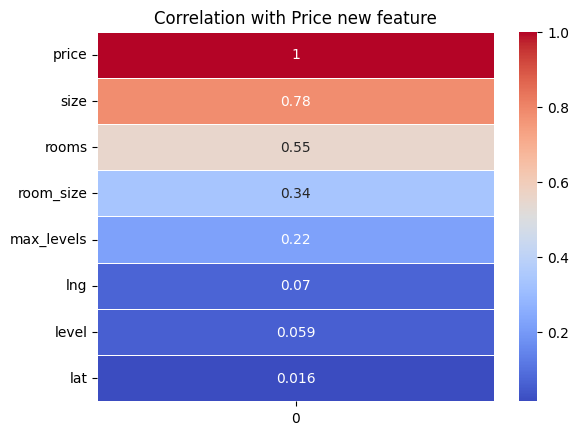

In [20]:
sns.heatmap(df.corrwith(df['price'], numeric_only=True).sort_values(ascending=False).to_frame(), annot=True, cmap='coolwarm', linewidths=0.7)
plt.title('Correlation with Price new feature')
plt.show()

In [ ]:
# Feature Engineering
df['is_first_floor'] = (df['level'] == 1).astype(int)
df['is_last_floor'] = (df['level'] == df['max_levels']).astype(int)
df['level_ratio'] = df['level'] / df['max_levels']
df.head()

,district,rooms,size,level,max_levels,price,lat,lng,room_size,is_first_floor,is_last_floor,level_ratio
0,Yunusobod,3,57.0,4,4,52000,41.371471,69.281049,19.000000,0,1,1.00
1,Yakkasaroy,2,52.0,4,5,56000,41.291115,69.261104,26.000000,0,0,0.80
2,Chilonzor,2,42.0,4,4,37000,41.280784,69.223683,21.000000,0,1,1.00
3,Chilonzor,3,65.0,1,4,49500,41.290163,69.196862,21.666667,1,0,0.25
4,Chilonzor,3,70.0,3,5,55000,41.300156,69.210831,23.333333,0,0,0.60


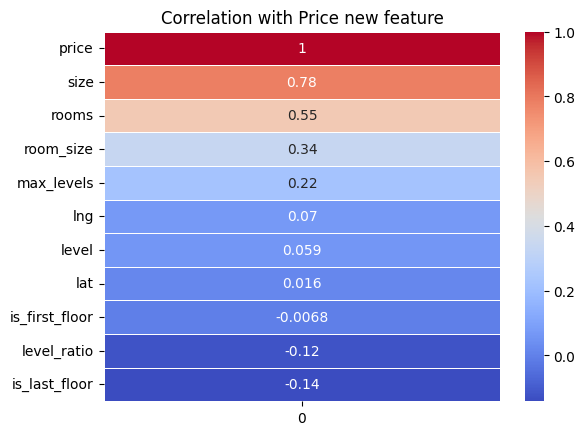

In [22]:
sns.heatmap(df.corrwith(df['price'], numeric_only=True).sort_values(ascending=False).to_frame(), annot=True, cmap='coolwarm', linewidths=0.7)
plt.title('Correlation with Price new feature')
plt.show()

In [ ]:
#Foyda bermadi bog'liqlik past olib tashlaymiz 
df = df.drop(columns=['is_first_floor', 'is_last_floor', 'level_ratio'])
df.head()

,district,rooms,size,level,max_levels,price,lat,lng,room_size
0,Yunusobod,3,57.0,4,4,52000,41.371471,69.281049,19.000000
1,Yakkasaroy,2,52.0,4,5,56000,41.291115,69.261104,26.000000
2,Chilonzor,2,42.0,4,4,37000,41.280784,69.223683,21.000000
3,Chilonzor,3,65.0,1,4,49500,41.290163,69.196862,21.666667
4,Chilonzor,3,70.0,3,5,55000,41.300156,69.210831,23.333333


In [27]:
# Toshkent markazi kordinatalari
center_lat = 41.3171
center_lng = 69.2797

# Haverzin formulasi asosida masofani hisoblash funksiyasi
def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6371 # Yer radiusi (kilometrda)
    
    # Kordinatalarni radianga o'tkazish
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Haverzin formulasi
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a)) 
    km = R * c
    return km

# Har bir uy uchun markazgacha bo'lgan masofani hisoblab, yangi ustunga yozamiz
df['distance_to_center'] = calculate_distance(df['lat'], df['lng'], center_lat, center_lng)

# Natijani ko'rish
df.head()

,district,rooms,size,level,max_levels,price,lat,lng,room_size,distance_to_center
0,Yunusobod,3,57.0,4,4,52000,41.371471,69.281049,19.000000,6.046816
1,Yakkasaroy,2,52.0,4,5,56000,41.291115,69.261104,26.000000,3.280449
2,Chilonzor,2,42.0,4,4,37000,41.280784,69.223683,21.000000,6.181035
3,Chilonzor,3,65.0,1,4,49500,41.290163,69.196862,21.666667,7.540109
4,Chilonzor,3,70.0,3,5,55000,41.300156,69.210831,23.333333,6.053005


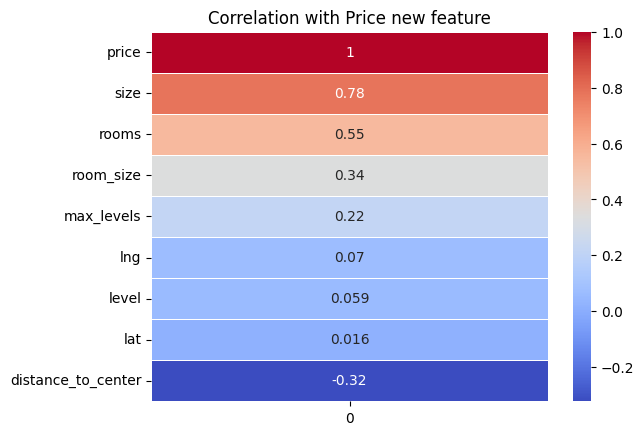

In [28]:
sns.heatmap(df.corrwith(df['price'], numeric_only=True).sort_values(ascending=False).to_frame(), annot=True, cmap='coolwarm', linewidths=0.7)
plt.title('Correlation with Price new feature')
plt.show()